In [1]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tardis.io.atom_data import AtomData
from tardis.io.configuration.config_reader import Configuration

home = Path.home()

ION_SLICE = (1, slice(None), slice(None), slice(None))

# identical atomic data to that used by C Vogl
atom_data = AtomData.from_hdf(home / "tardis-regression-data/atom_data/nlte_atom_data/TestNLTE_He_Ti_ctardis.h5") # currently not available for public use

config = Configuration.from_yaml(home / "tardis/tardis/plasma/tests/data/plasma_base_test_config.yml")

config.supernova.time_explosion = 16.084 * u.day
config.model.structure.type = "file"
config.model.structure.filename = home / "tardis/docs/physics/plasma/equilibrium/cmfgen_stephane_density_rebin.dat"
config.model.structure.filetype = "simple_ascii"
config.model.structure.v_inner_boundary = 10000 * u.km / u.s
config.model.structure.v_outer_boundary = 15000 * u.km / u.s

config.model.abundances.He = 0
config.model.abundances.H = 1

config.plasma.excitation = "dilute-lte"
config.plasma.ionization = "nebular"

config.plasma.continuum_interaction.species = ["H 1"]
config.plasma.nlte.species = ["H 1"]

/home/afullard/tardis/tardis/__init__.py:17: UserWarning: Astropy is already imported externally. Astropy should be imported after TARDIS.
  warnings.warn(


### Set up electrons and radiation field

First plasma solution BEFORE MC step

In [2]:
from tardis.plasma.electron_energy_distribution import (
         ThermalElectronEnergyDistribution,
)
from tardis.plasma.radiation_field import (
    DilutePlanckianRadiationField,
)

radiation_temp = 10000 * np.ones(1) * u.K
dilution_factor = 0.5 * np.ones(1)

electron_temp = 10000 * np.ones(1)
electron_density = 2206878889.9599175 * np.ones(1)

elemental_number_density = pd.DataFrame(2.20691862e+09 * np.ones(1), index=[1])
elemental_number_density.index.name = "atomic_number"

thermal_electron_distribution = ThermalElectronEnergyDistribution(0 * u.erg, electron_temp * u.K, electron_density * u.cm**-3)
radiation_field = DilutePlanckianRadiationField(radiation_temp, dilution_factor)

### Set up plasma

In [3]:
from tardis.plasma.assembly.base import PlasmaSolverFactory

plasma_solver_factory = PlasmaSolverFactory(atom_data, config)
plasma_solver_factory.prepare_factory([1],"tardis.plasma.properties.property_collections", config=config)
plasma = plasma_solver_factory.assemble(elemental_number_density, radiation_field, 16.084 * u.day, thermal_electron_distribution.number_density, link_t_rad_t_electron=1)

Zeta_data missing - replaced with 1s. Missing ions: []
Zeta_data missing - replaced with 1s. Missing ions: []


In [4]:
ctardis_lines = pd.read_csv("/home/afullard/tardis-chvogl-configs/ctardis_lines.csv", index_col=(0,))

In [5]:
# Find lines present in ctardis_lines but not in plasma atom_data lines
plasma_lines = atom_data.lines.loc[ION_SLICE, :]

# Create MultiIndex for ctardis_lines to match plasma lines structure
ctardis_multiindex = pd.MultiIndex.from_arrays([
    ctardis_lines['atomic_number'].values,
    ctardis_lines['ion_number'].values,
    ctardis_lines['level_number_lower'].values.astype(int),
    ctardis_lines['level_number_upper'].values.astype(int)
], names=['atomic_number', 'ion_number', 'level_number_lower', 'level_number_upper'])

ctardis_lines_indexed = ctardis_lines.copy()
ctardis_lines_indexed.index = ctardis_multiindex

# Find lines in ctardis but not in plasma
ctardis_only = ctardis_lines_indexed.index.difference(plasma_lines.index)
print(f"Lines in ctardis_lines but not in plasma.atom_data.lines: {len(ctardis_only)}")

# Find lines present in both ctardis and plasma
common_lines = ctardis_lines_indexed.index.intersection(plasma_lines.index)
print(f"Lines in both ctardis_lines and plasma.atom_data.lines: {len(common_lines)}")

# Create list of indices for ctardis_lines that correspond to lines present in atom_data.lines
common_indices = []
for idx, line_index in enumerate(ctardis_lines_indexed.index):
    if line_index in plasma_lines.index:
        common_indices.append(idx)

print(f"Number of common line indices: {len(common_indices)}")

Lines in ctardis_lines but not in plasma.atom_data.lines: 16
Lines in both ctardis_lines and plasma.atom_data.lines: 419
Number of common line indices: 419


import networkx as nx

A = nx.nx_agraph.to_agraph(plasma.graph)
A.layout(prog='dot')
A.draw('equilibrium_plasma_tardis_nlte.png')

A = nx.read_graphml("/home/afullard/tardis-chvogl-configs/plasma_graph.gml")
A = nx.nx_agraph.to_agraph(A)
A.layout(prog='dot')
A.draw('equilibrium_plasma_ctardis.png')

In [6]:
plasma.ion_number_density

0
atomic_number ion_number              
1             0           3.971250e+04
              1           2.206879e+09

In [7]:
plasma.level_number_density.head()

0
atomic_number ion_number level_number              
1             0          0             39697.089101
                         1                 0.580010
                         2                 0.118246
                         3                 0.088475
                         4                 0.091110

In [8]:
plasma.partition_function

0
atomic_number ion_number          
1             0           2.000776
              1           1.000000

In [9]:
plasma.general_level_boltzmann_factor.head()

0
atomic_number ion_number level_number          
1             0          0             2.000000
                         1             0.000029
                         2             0.000006
                         3             0.000004
                         4             0.000005

In [10]:
plasma.electron_densities

0    2.206879e+09
dtype: float64

In [11]:
plasma.phi

,,0
atomic_number,ion_number,
1,1,1.226393e+14


In [12]:
plasma.level_boltzmann_factor.head()

0
atomic_number ion_number level_number          
1             0          0             2.000000
                         1             0.000029
                         2             0.000006
                         3             0.000004
                         4             0.000005

### Outputs above are close matches for ctardis before the first NLTE calculation

# Update plasma following ctardis

Also update radiation field and electron distribution

In [13]:
radiation_field.temperature = 9984 * np.ones(1) * u.K
radiation_field.dilution_factor = 0.18635244 * np.ones(1)

thermal_electron_distribution.number_density = plasma.electron_densities.values * u.cm**-3
thermal_electron_distribution.temperature = 9984 * np.ones(1) * u.K

# not updating the plasma, because then it recomputes the ion number density input for the NLTE calculation
#plasma.update(dilute_planckian_radiation_field=radiation_field)

### Set up ionization rate solvers

In [14]:
from tardis.plasma.equilibrium.rate_matrix import IonRateMatrix
from tardis.plasma.equilibrium.rates import (
         AnalyticPhotoionizationRateSolver,
         CollisionalIonizationRateSolver,
         EstimatedPhotoionizationRateSolver,
)

analytic_photoionization_rate_solver = AnalyticPhotoionizationRateSolver(atom_data.photoionization_data)
estimated_photoionization_rate_solver = EstimatedPhotoionizationRateSolver(atom_data.photoionization_data, atom_data.level2continuum_edge_idx)

collisional_ionization_rate_solver = CollisionalIonizationRateSolver(atom_data.photoionization_data)

analytic_ion_rate_matrix_solver = IonRateMatrix(analytic_photoionization_rate_solver, collisional_ionization_rate_solver)
estimated_ion_rate_matrix_solver = IonRateMatrix(estimated_photoionization_rate_solver, collisional_ionization_rate_solver)

### Required LTE properties

In [15]:
from tardis.plasma.properties.hydrogen_continuum import (
    LTEIonNumberDensity,
    LTELevelNumberDensity,
)


def calculate_lte_properties(plasma, electron_densities):
    lte_ion_number_density = LTEIonNumberDensity(plasma,
                                                electron_densities=electron_densities
                                                ).calculate(
                                                    plasma.thermal_phi_lte,
                                                    plasma.thermal_lte_partition_function,
                                                    plasma.number_density,
                                                    pd.DataFrame(electron_densities),
                                                    None)[0]

    lte_level_number_density = LTELevelNumberDensity(plasma
                                                    ).calculate(
                                                        plasma.thermal_lte_level_boltzmann_factor,
                                                        lte_ion_number_density,
                                                        plasma.levels,
                                                        plasma.thermal_lte_partition_function)
    return lte_ion_number_density, lte_level_number_density

In [16]:
lte_ion_number_density, lte_level_number_density = calculate_lte_properties(plasma, thermal_electron_distribution.number_density.value)

In [17]:
lte_ion_number_density

0
atomic_number ion_number              
1             0           1.440887e+04
              1           2.206904e+09

In [18]:
lte_level_number_density.head()

0
atomic_number ion_number level_number              
1             0          0             14388.374917
                         1                 0.416954
                         2                 0.104814
                         3                 0.086527
                         4                 0.094792

### LTE inputs very close to ctardis

In [19]:
from tardis.plasma.equilibrium.ion_populations import IonPopulationSolver

analytic_ion_number_density_solver = IonPopulationSolver(analytic_ion_rate_matrix_solver)

# CTARDIS uses first guesses as previous ion density, single ionized, 
# fully ionized, neutral, and equal number density for each stage (in that order)

ion_number_density_first_guess = pd.DataFrame(np.vstack([1.541454e+05, 2.206764e+09]), index=plasma.ion_number_density.index)

Basic CTARDIS ion number density, matches basic TARDIS ion number density:

```
1             0           3.972550e+04
              1           2.206879e+09
```

Pre-NLTE iteration CTARDIS ion number density, uses PhiSahaNebular only as rate:

```       
1             0           1.435241e+05
              1           2.206775e+09
```

First NLTE iteration CTARDIS ion number density, uses estimators as rates:

```
1             0           1.541454e+05
              1           2.206764e+09
```

Second NLTE iteration...

```
1             0           2.068727e+05
              1           2.206712e+09
```

Fifth NLTE iteration...

```
1             0           1.939847e+05
              1           2.206725e+09 
```

8th NLTE iteration...

```
1             0           1.936496e+05
              1           2.206725e+09
```

Final...

```
1             0           1.936493e+05
              1           2.206725e+09
```

This method converges quickly to a different answer. However, CTARDIS solves the equation using LTE for the first iteration. This method uses analytic NLTE based on the radiation field instead.

In [20]:
analytic_ion_number_density, analytic_electron_number_density = (
    analytic_ion_number_density_solver.solve_analytic(
        radiation_field,
        thermal_electron_distribution,
        plasma.number_density,
        lte_level_number_density,
        plasma.level_number_density,
        lte_ion_number_density,
        #plasma.ion_number_density,
        ion_number_density_first_guess,
        plasma.partition_function,
        plasma.general_level_boltzmann_factor,
    )
)

In [21]:
analytic_ion_number_density

0
atomic_number ion_number              
1             0           5.908561e+04
              1           2.206860e+09

# Load $J_{blues}$ and create an estimated radiation field

In [22]:
j_blues_ctardis = pd.read_csv("/home/afullard/tardis-chvogl-configs/j_blues.csv", index_col=0)

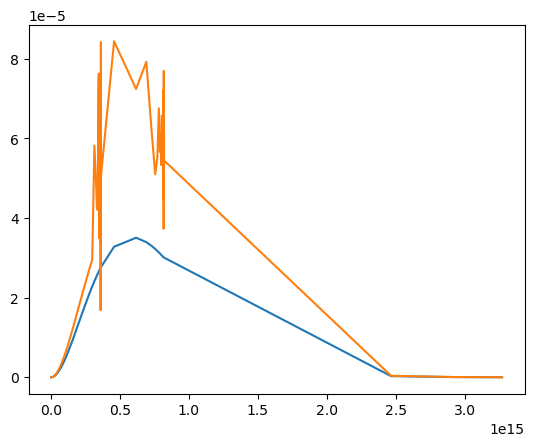

In [23]:
plt.plot(atom_data.lines.loc[ION_SLICE, :].nu.values * u.Hz, radiation_field.calculate_mean_intensity(atom_data.lines.loc[ION_SLICE, :].nu.values * u.Hz))
plt.plot(atom_data.lines.loc[ION_SLICE, :].nu, j_blues_ctardis.iloc[common_indices, 0])

In [24]:
class EstimatedRadiationField:
    def __init__(self, temperature, j_blues):
        self.j_blues = j_blues
        self.temperature = temperature

    def calculate_mean_intensity(self, nu):
        return self.j_blues.values

estimated_radiation_field = EstimatedRadiationField(9984 * np.ones(1) * u.K, j_blues_ctardis.iloc[common_indices, 0])

In [25]:
def solve_ion_number_density(species, phis, number_density, phi_nlte):
    number_ratio_matrix = np.diag(np.ones(species[0]), k=1)
    number_ratio_matrix[-1] = 1.
    diag_indices = np.diag_indices(len(number_ratio_matrix) - 1)
    number_ratio_matrix[diag_indices] = -phis
    number_ratio_matrix[species[1], species[1]] = -phi_nlte
    number_conservation_vec = np.zeros(len(number_ratio_matrix))
    number_conservation_vec[-1] = number_density
    ion_numbers = np.linalg.solve(number_ratio_matrix,
                                    number_conservation_vec)
    return ion_numbers

# Full NLTE and continuum calculation of the level Boltzmann factor

In [42]:
from tardis.plasma.equilibrium.rate_matrix import RateMatrix
from tardis.plasma.equilibrium.rates import (
    CollisionalIonizationSeaton,
    RadiativeRatesSolver,
    ScaledRadiativeRatesSolver,
    SpontaneousRecombinationCoeffSolver,
    ThermalCollisionalRateSolver,
)

lower_ion_level_index = (
            lte_level_number_density.index.get_level_values("ion_number")
            == 0
        )

upper_ion_population_index = (
            lte_ion_number_density.index.get_level_values("ion_number")
            > 0
        )


def _main_nlte_cont_calculation(
        atomic_data,
        nlte_data,
        t_electrons,
        estimated_radiation_field,
        previous_electron_densities,
        previous_ion_number_density, 
        rad_field_mc_estimators,
        lte_ion_number_density,
        lte_level_number_density
        ):
    """
    The core of the NLTE calculation, used with all possible config.
    options.
    """
    # A fake electron distribution. Will eventually be a direct input
    # to the plasma property.
    electron_distribution = ThermalElectronEnergyDistribution(
        0 * u.erg,
        t_electrons * u.K,
        previous_electron_densities * u.g / u.cm**3,
    )

    for species in nlte_data.nlte_species:
        species_slice = (species[0], species[1], slice(None), slice(None))
        radiative_transitions = atomic_data.lines.loc[species_slice, :]
        # investigating
        #radiative_rate_solver = ScaledRadiativeRatesSolver(radiative_transitions)
        radiative_rate_solver = RadiativeRatesSolver(radiative_transitions)

        if atomic_data.collision_data == "dummy value":
            col_strengths = atomic_data.yg_data.loc[species_slice, :]
            col_type = "cmfgen"
        else:
            col_strengths = atomic_data.collision_data.loc[species_slice, :]
            col_type = "chianti"

        col_strength_temperatures = atomic_data.collision_data_temperatures

        collisional_rate_solver = ThermalCollisionalRateSolver(
            atomic_data.levels,
            radiative_transitions,
            col_strength_temperatures,
            col_strengths,
            col_type,
        )

        # still investigating if this is needed
        #radiative_rates = radiative_rate_solver.solve(estimated_radiation_field, beta_sobolevs[species_slice])
        #collisional_rates = collisional_rate_solver.solve(electron_distribution.temperature)

        rate_solvers = [
                (radiative_rate_solver, "radiative"),
                (collisional_rate_solver, "electron"),
            ]

        rate_matrix_solver = RateMatrix(rate_solvers, atomic_data.levels)

        excitation_rate_matrix = rate_matrix_solver.solve(estimated_radiation_field, electron_distribution)

        collisional_ionization_coeff_solver = CollisionalIonizationSeaton(atom_data.photoionization_data)
        collisional_ionization_rate = collisional_ionization_coeff_solver.solve(electron_distribution.temperature)

        estimated_photoionization_rate = rad_field_mc_estimators.photo_ion_estimator
        estimated_stim_recomb_rate = rad_field_mc_estimators.stim_recomb_estimator * previous_electron_densities

        spontaneous_recomb_rate_solver = SpontaneousRecombinationCoeffSolver(atom_data.photoionization_data)
        spontaneous_recomb_rate = spontaneous_recomb_rate_solver.solve(electron_distribution.temperature) * previous_electron_densities

        level_to_ion_population_factor = pd.DataFrame(
        lte_level_number_density.loc[lower_ion_level_index].values / (
            lte_ion_number_density.loc[upper_ion_population_index].values
            * thermal_electron_distribution.number_density.value
        ),
        index = lte_level_number_density.loc[lower_ion_level_index].index)

        collisional_recomb_rate = collisional_ionization_rate * level_to_ion_population_factor * previous_electron_densities ** 2

        ionization_rate_vector = estimated_photoionization_rate + collisional_ionization_rate
        ionization_rate_vector.iloc[0] = 0

        ionization_rate_matrix = -np.diag(ionization_rate_vector[0].values)

        recombination_rate_vector = estimated_stim_recomb_rate + spontaneous_recomb_rate + collisional_recomb_rate
        total_inverse_recombination_rate = -recombination_rate_vector.sum()

        total_rate_matrix = np.append(excitation_rate_matrix.values[0, 0] + ionization_rate_matrix, np.expand_dims(ionization_rate_vector[0].values, 1), axis=1)

        total_rate_matrix = np.append(total_rate_matrix, [np.hstack([ionization_rate_vector[0].values, total_inverse_recombination_rate])], axis=0)

        number_conservation_vec = np.zeros(total_rate_matrix.shape[0])
        number_conservation_vec[0] = 1.0

        solutions = np.linalg.solve(total_rate_matrix, number_conservation_vec)

    return solutions

In [43]:
class DummyEstimators:
    def __init__(self, photo_ion_estimator, stim_recomb_estimator):
        self.photo_ion_estimator = photo_ion_estimator
        self.stim_recomb_estimator = stim_recomb_estimator

photo_ion_estimator = pd.read_csv("/home/afullard/tardis-chvogl-configs/photo_ion_estimator.csv", index_col=(0))
stim_recomb_estimator = pd.read_csv("/home/afullard/tardis-chvogl-configs/stim_recomb_estimator.csv", index_col=(0))

photo_ion_estimator.columns = photo_ion_estimator.columns.astype(int)
stim_recomb_estimator.columns = stim_recomb_estimator.columns.astype(int)
# Create MultiIndex for photo_ion_estimator
photo_ion_estimator_idx = pd.MultiIndex.from_tuples(
    [(1, 0, level) for level in photo_ion_estimator.index],
    names=['atomic_number', 'ion_number', 'level_number']
)
photo_ion_estimator.index = photo_ion_estimator_idx

# Create MultiIndex for stim_recomb_estimator
stim_recomb_estimator_idx = pd.MultiIndex.from_tuples(
    [(1, 0, level) for level in stim_recomb_estimator.index],
    names=['atomic_number', 'ion_number', 'level_number']
)
stim_recomb_estimator.index = stim_recomb_estimator_idx

rad_field_mc_estimators = DummyEstimators(photo_ion_estimator.loc[:, [0]], stim_recomb_estimator.loc[:, [0]])

In [50]:
nlte_continuum_solution = _main_nlte_cont_calculation(plasma.atomic_data, plasma.nlte_data, plasma.t_electrons, estimated_radiation_field, plasma.electron_densities, plasma.ion_number_density, rad_field_mc_estimators, lte_ion_number_density, lte_level_number_density)

In [51]:
time_simulation = 7.2671371e-44 * u.s
volume = 1.61751052e44 * np.ones(1) * u.cm**3

# Level population fractions

CTARDIS uses the j_blues to compute the radiative rates. It also includes the ionization rates in the matrix. These are used to solve for the Boltzmann factor at each level

In [52]:
level_pop_fractions = pd.read_csv("/home/afullard/tardis-chvogl-configs/level_pop_fractions.csv", index_col=(0,1,2))
level_pop_fractions.columns = level_pop_fractions.columns.astype(int)

In [53]:
tardis_level_pop_fractions = plasma.level_boltzmann_factor / plasma.partition_function

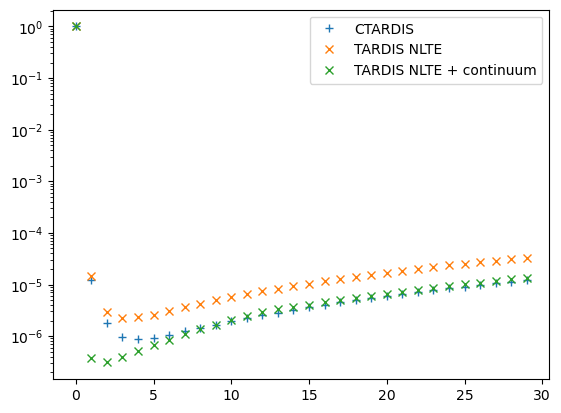

In [59]:
plt.semilogy(level_pop_fractions.loc[:, [0]].values, "+", label="CTARDIS")
plt.semilogy(tardis_level_pop_fractions.loc[(1, 0, slice(None)), [0]].values, "x", label="TARDIS NLTE")
plt.semilogy(nlte_continuum_solution[:-1], "x", label="TARDIS NLTE + continuum")
plt.legend()

In [55]:
estimated_ion_number_density_solver = IonPopulationSolver(estimated_ion_rate_matrix_solver)

lte_ion_number_density, lte_level_number_density = calculate_lte_properties(plasma, thermal_electron_distribution.number_density.value)

ion_number_density_first_guess, electron_number_density_first_guess = estimated_ion_number_density_solver.solve_estimated(
    thermal_electron_distribution,
    rad_field_mc_estimators,
    plasma.number_density,
    time_simulation,
    volume,
    lte_level_number_density,
    plasma.level_number_density,
    lte_ion_number_density,
    #ion_number_density_first_guess,
    plasma.ion_number_density,
    plasma.partition_function,
    plasma.general_level_boltzmann_factor,)

In [ ]:
ion_number_density_first_guess

### Set up bound-bound rate solvers

In [ ]:
from tardis.plasma.equilibrium.rates import (
    RadiativeRatesSolver,
    ThermalCollisionalRateSolver,
)

radiative_rate_solver = RadiativeRatesSolver(atom_data.lines.loc[ION_SLICE, :])

collisional_bound_rate_solver = ThermalCollisionalRateSolver(
    atom_data.levels,
    atom_data.lines.loc[ION_SLICE, :],
    atom_data.collision_data_temperatures,
    atom_data.yg_data.loc[atom_data.lines.loc[ION_SLICE, :].index], # handles the issue that there is more collision than line data
    "cmfgen",
    "regemorter")

rate_solvers = [(radiative_rate_solver, "radiative"), (collisional_bound_rate_solver, "electron")]

In [ ]:
from tardis.plasma.equilibrium.level_populations import LevelPopulationSolver
from tardis.plasma.equilibrium.rate_matrix import RateMatrix

rate_matrix_solver = RateMatrix(rate_solvers, atom_data.levels.loc[ION_SLICE, :])

rate_matrix = rate_matrix_solver.solve(radiation_field, thermal_electron_distribution)

In [ ]:
level_pop_solver = LevelPopulationSolver(rate_matrix, atom_data.levels.loc[ION_SLICE, :])

level_number_density_first_guess = level_pop_solver.solve() * ion_number_density_first_guess

In [ ]:
level_number_density_first_guess.head()

# Using $J_{blues}$ for radiation field

In [ ]:
rate_matrix = rate_matrix_solver.solve(estimated_radiation_field, thermal_electron_distribution)

In [ ]:
level_pop_solver = LevelPopulationSolver(rate_matrix, atom_data.levels.loc[ION_SLICE, :])

level_number_density_first_guess = level_pop_solver.solve() * ion_number_density_first_guess

In [ ]:
level_number_density_first_guess.head()

### Set up thermal balance solver

In [ ]:
from tardis.plasma.equilibrium.rates.heating_cooling_rates import (
         BoundFreeThermalRates,
         CollisionalBoundThermalRates,
         CollisionalIonizationThermalRates,
         FreeFreeThermalRates,
)

bf_rates = BoundFreeThermalRates(atom_data.photoionization_data)
ff_rates = FreeFreeThermalRates()
coll_ion_rates = CollisionalIonizationThermalRates(atom_data.photoionization_data)
coll_bound_rates = CollisionalBoundThermalRates(atom_data.lines.loc[ION_SLICE, :])

In [ ]:
data_path = home / "tardis-regression-data/testdata/thermal_data"
bf_heating_estimator = pd.read_csv(data_path / "thermal_bf_heating_est.csv", index_col=(0, 1, 2))
stim_recomb_cooling_estimator = pd.read_csv(data_path / "thermal_stim_cooling_est.csv", index_col=(0, 1, 2))
level_population_ratio = pd.read_csv(data_path / "thermal_level_pop_ratio.csv", index_col=(0, 1, 2))
coll_exc_coeff = pd.read_csv(data_path / "thermal_coll_exc_coeff.csv", index_col=(0, 1, 2, 3))
coll_deexc_coeff = pd.read_csv(data_path / "thermal_coll_deexc_coeff.csv", index_col=(0, 1, 2, 3))
coll_ion_rate_coeff = pd.read_csv(data_path / "thermal_coll_ion_rate_coeff.csv", index_col=(0, 1, 2))

ff_heating_estimator = [  4.89135279e-24,   4.37696370e-24,   3.75869301e-24,
         4.97847160e-24,   4.52158002e-24,   4.21024499e-24,
         3.94991540e-24,   3.72915649e-24,   3.58902110e-24,
         3.40170224e-24,   3.20848519e-24,   3.03540032e-24,
         2.87314722e-24,   2.74328938e-24,   2.61063140e-24,
         2.50640248e-24,   2.38164559e-24,   2.26967531e-24,
         2.24509826e-24,   2.12378192e-24,   2.02063266e-24,
         1.92509873e-24,   1.83070678e-24,   1.77346374e-24]

# because pandas reads in the columns as strings, we need to convert them back to integers
bf_heating_estimator.columns = bf_heating_estimator.columns.astype(int)
stim_recomb_cooling_estimator.columns = stim_recomb_cooling_estimator.columns.astype(int)
level_population_ratio.columns = level_population_ratio.columns.astype(int)
coll_exc_coeff.columns = coll_exc_coeff.columns.astype(int)
coll_deexc_coeff.columns = coll_deexc_coeff.columns.astype(int)
coll_ion_rate_coeff.columns = coll_ion_rate_coeff.columns.astype(int)

In [ ]:
from tardis.plasma.equilibrium.rates.collisional_ionization_strengths import (
         CollisionalIonizationSeaton,
)
from tardis.plasma.equilibrium.thermal_balance import ThermalBalanceSolver

collisional_ionization_rate_coeff = CollisionalIonizationSeaton(atom_data.photoionization_data).solve(thermal_electron_distribution.temperature)
collisional_bound_rate_coeff = collisional_bound_rate_solver.solve(thermal_electron_distribution.temperature)

thermal_solver = ThermalBalanceSolver(bf_rates, ff_rates, coll_ion_rates, coll_bound_rates)

heating_rate, fractional_heating_rate = thermal_solver.solve(
    thermal_electron_distribution,
    level_number_density_first_guess.loc[:, [0]],
    ion_number_density_first_guess.loc[:, [0]],
    collisional_ionization_rate_coeff.loc[:, [0]],
    collisional_bound_rate_coeff.iloc[419:, [0]],
    collisional_bound_rate_coeff.iloc[:419, [0]],
    ff_heating_estimator[0],
    level_population_ratio.loc[:, [0]],
    bound_free_heating_estimator=bf_heating_estimator.loc[:, [0]],
    stimulated_recombination_estimator=stim_recomb_cooling_estimator.loc[:, [0]],
)

## Thermal balance sanity checks

In [ ]:
coll_ion_rate_coeff.loc[:, [0]].plot()
collisional_ionization_rate_coeff.plot()

In [ ]:
collisional_bound_rate_coeff.iloc[419:, [0]].plot(logy=True, marker='.', ls="None")
coll_deexc_coeff_swapped = coll_deexc_coeff.swaplevel("level_number_destination", "level_number_source", axis=0)
coll_deexc_coeff_swapped.loc[:, [0]].plot(logy=True, marker='.', ls="None")

In [ ]:
collisional_bound_rate_coeff.iloc[:419, [0]].plot(logy=True, marker='.', ls="None")
coll_exc_coeff.sort_index(inplace=True)
coll_exc_coeff.loc[:, [0]].plot(logy=True, marker='.', ls="None")

In [ ]:
import matplotlib.pyplot as plt

plt.semilogy(coll_exc_coeff.loc[:, [0]].values, marker='.', ls="None")
plt.semilogy(coll_deexc_coeff.loc[:, [0]].values, marker='.', ls="None")

In [ ]:
plt.semilogy(collisional_bound_rate_coeff.iloc[:419, [0]].values, marker='.', ls="None")
plt.semilogy(collisional_bound_rate_coeff.iloc[419:, [0]].values, marker='.', ls="None")

# Update properties after first MC process

In [ ]:
thermal_electron_distribution.number_density = electron_number_density_first_guess.to_numpy() * u.cm**-3

radiation_field.temperature = 9992 * np.ones(1) * u.K
radiation_field.dilution_factor = 0.3571996 * np.ones(1)

In [ ]:
# initial link guess
plasma.update(
    link_t_rad_t_electron = radiation_field.dilution_factor ** 0.25, 
    previous_level_number_density=level_number_density_first_guess, 
    previous_ion_number_density=ion_number_density_first_guess)

max_electron_density = (plasma.number_density * plasma.number_density.index.values).sum()

fractional_electron_density = thermal_electron_distribution.number_density / max_electron_density

print("Initial fractional electron density:\n", fractional_electron_density.values)
print("Initial heating fraction:\n", fractional_heating_rate.values)

In [ ]:
def calculate_electron_density_fractional_heating(
        inputs,
        plasma,
        radiation_field,
        ion_solver,
        rate_matrix_solver,
        thermal_solver,
    ):
    fractional_electron_density = inputs[::2]
    link_t_rad_t_electron = inputs[1::2]

    plasma.update(link_t_rad_t_electron=link_t_rad_t_electron, previous_electron_densities = fractional_electron_density * max_electron_density.values)

    thermal_electron_distribution = ThermalElectronEnergyDistribution(
        0 * u.erg,
        plasma.t_electrons * u.K,
        plasma.previous_electron_densities * u.cm**-3,
    )

    lte_ion_number_density, lte_level_number_density = calculate_lte_properties(plasma, thermal_electron_distribution.number_density.value)

    ion_number_density, electron_number_density = ion_solver.solve_estimated(
        thermal_electron_distribution,
        rad_field_mc_estimators,
        plasma.number_density,
        time_simulation,
        volume,
        lte_level_number_density,
        plasma.previous_level_number_density,
        lte_ion_number_density,
        plasma.previous_ion_number_density,
        plasma.partition_function,
        plasma.general_level_boltzmann_factor,
        tolerance=1e-8,)

    fractional_electron_density_change = (electron_number_density - thermal_electron_distribution.number_density.value) / thermal_electron_distribution.number_density.value

    thermal_electron_distribution.number_density = electron_number_density.to_numpy() * u.cm**-3

    rate_matrix = rate_matrix_solver.solve(radiation_field, thermal_electron_distribution)
    level_pop_solver = LevelPopulationSolver(rate_matrix, atom_data.levels.loc[ION_SLICE, :])
    level_number_density = level_pop_solver.solve() * ion_number_density

    plasma.update(previous_level_number_density=level_number_density, previous_ion_number_density=ion_number_density)

    collisional_ionization_rate_coeff = CollisionalIonizationSeaton(atom_data.photoionization_data).solve(thermal_electron_distribution.temperature)
    collisional_bound_rate_coeff = collisional_bound_rate_solver.solve(thermal_electron_distribution.temperature)

    level_to_ion_population_factor = pd.DataFrame(
        lte_level_number_density.loc[lower_ion_level_index].values / (
            lte_ion_number_density.loc[upper_ion_population_index].values
            * thermal_electron_distribution.number_density.value
        ),
        index = lte_level_number_density.loc[lower_ion_level_index].index)


    heating_rate, fractional_heating_rate = thermal_solver.solve(
        thermal_electron_distribution,
        level_number_density.loc[:, [0]],
        ion_number_density.loc[:, [0]],
        collisional_ionization_rate_coeff.loc[:, [0]],
        collisional_bound_rate_coeff.iloc[419:, [0]],
        collisional_bound_rate_coeff.iloc[:419, [0]],
        ff_heating_estimator[0],
        level_to_ion_population_factor.loc[:, [0]],
        bound_free_heating_estimator=bf_heating_estimator.loc[:, [0]],
        stimulated_recombination_estimator=stim_recomb_cooling_estimator.loc[:, [0]],
    )

    print("Fractional change in e- density:\n", fractional_electron_density_change.values)
    print("Fractional heating rate:\n", fractional_heating_rate.values)
    print("Temperature:\n", plasma.t_electrons)
    output = np.zeros(2 * len(radiation_field.temperature))
    output[::2] = fractional_electron_density_change.values
    output[1::2] = fractional_heating_rate.values
    return output

In [ ]:
from scipy.optimize import least_squares
from scipy.sparse import block_diag

initial = np.zeros(2 * len(radiation_field.dilution_factor))
initial[::2] = fractional_electron_density.values
initial[1::2] = radiation_field.dilution_factor ** 0.25

jac_sparsity = block_diag([np.ones((2, 2))] * 1)

In [ ]:
result = least_squares(calculate_electron_density_fractional_heating,
              initial,
              bounds=([0.0, 0.15], [1.0, 1.0]),
              args=(plasma, radiation_field, estimated_ion_number_density_solver, rate_matrix_solver, thermal_solver),
              xtol=1e-14,
              ftol=1e-12,
              gtol=1e-14,
              x_scale='jac',
              jac_sparsity=jac_sparsity,
              verbose=2,
              max_nfev=100)

In [ ]:
result.status

In [ ]:
result.x

In [ ]:
0.99992139 * max_electron_density[0]

In [ ]:
initial = np.zeros(20)
initial[::2] = np.ones(10) * 0.99993015 #np.linspace(0.999, 1.0, 10)
initial[1::2] = np.linspace(0.5, 0.9, 10)

In [ ]:
outputs = []

for i in range(0, len(initial), 2):
    input_pair = initial[i:i+2]
    print(input_pair)
    outputs.append(calculate_electron_density_fractional_heating(input_pair, plasma, radiation_field, estimated_ion_number_density_solver, rate_matrix_solver, thermal_solver))

In [ ]:
plt.plot(initial[1::2], np.array(outputs)[:, 1])
plt.plot(initial[1::2], np.array(outputs)[:, 0])